Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap
import optuna
import joblib


Loading Feature-Engineered Dataset

In [2]:
df = pd.read_csv("../data/processed/features.csv")

X = df.drop(columns=["target_next_runs"])
y = df["target_next_runs"]

X.head()

,career_avg,recent_3_avg,recent_5_avg,recent_10_avg,strike_rate,boundary_ratio,consistency_score,momentum,venue_adjusted_runs,pvt_avg,experience_log
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.693147
1,158.0,158.0,158.0,158.0,205.194805,0.294872,0.0,0.0,7.344011,37.933333,0.693147
2,6.0,6.0,6.0,6.0,60.000000,0.000000,0.0,0.0,0.278886,15.833333,0.693147
3,12.0,12.0,12.0,12.0,100.000000,0.076923,0.0,0.0,0.557773,25.625000,0.693147
4,8.0,8.0,8.0,8.0,114.285714,0.125000,0.0,0.0,0.371849,27.200000,0.693147


Time-series Aware Train-Test Split

In [3]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


Train Random Forest

In [4]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 12],
    "min_samples_split": [5, 10]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, rf_pred))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("RF R2:", r2_score(y_test, rf_pred))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
RF MAE: 17.003820046294162
RF RMSE: 22.228152491839833
RF R2: 0.08307206470990292


Train XGBoost

In [8]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("XGB R2:", r2_score(y_test, xgb_pred))


XGB MAE: 17.784417995916293
XGB RMSE: 23.56069159893592
XGB R2: -0.030159657511580562


Train LightGBM

In [15]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=12,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

print("LightGBM MAE:", mean_absolute_error(y_test, lgbm_pred))
print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgbm_pred)))
print("LightGBM R2:", r2_score(y_test, lgbm_pred))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2723
[LightGBM] [Info] Number of data points in the train set: 13072, number of used features: 11
[LightGBM] [Info] Start training from score 20.347843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

Model Comparison

In [16]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "MAE": [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, lgbm_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
        np.sqrt(mean_squared_error(y_test, lgbm_pred))
    ],
    "R2": [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred),
        r2_score(y_test, lgbm_pred)
    ]
})

results


,Model,MAE,RMSE,R2
0,Random Forest,17.003820,22.228152,0.083072
1,XGBoost,17.784418,23.560692,-0.030160
2,LightGBM,17.092608,22.536062,0.057493


Hyperparameter Tuning for ALL Models

1. RANDOM FOREST — GridSearchCV

In [17]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, 16],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [1, 2]
}


In [18]:
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

print("Best RF Params:", rf_grid.best_params_)
print("Tuned RF MAE:", mean_absolute_error(y_test, rf_pred))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Tuned RF R2:", r2_score(y_test, rf_pred))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best RF Params: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Tuned RF MAE: 16.78960551081953
Tuned RF RMSE: 22.007993255153487
Tuned RF R2: 0.101145581225491


2.XGBOOST — Optuna

In [21]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)


In [20]:
xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(xgb_objective, n_trials=30)

best_xgb = XGBRegressor(**xgb_study.best_params)
best_xgb.fit(X_train, y_train)

xgb_pred = best_xgb.predict(X_test)

print("Best XGB Params:", xgb_study.best_params)
print("Tuned XGB MAE:", mean_absolute_error(y_test, xgb_pred))
print("Tuned XGB RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("Tuned XGB R2:", r2_score(y_test, xgb_pred))


[I 2026-02-07 07:37:13,220] A new study created in memory with name: no-name-681e7f7d-1372-48fe-b2f6-ddb7302566c2
[I 2026-02-07 07:37:15,536] Trial 0 finished with value: 17.95820554120596 and parameters: {'n_estimators': 339, 'learning_rate': 0.05483355147791806, 'max_depth': 8, 'subsample': 0.8822984996750884, 'colsample_bytree': 0.6886425682618085}. Best is trial 0 with value: 17.95820554120596.
[I 2026-02-07 07:37:16,565] Trial 1 finished with value: 18.493622404107118 and parameters: {'n_estimators': 340, 'learning_rate': 0.1071750721990185, 'max_depth': 5, 'subsample': 0.8906244636016636, 'colsample_bytree': 0.8368138517909849}. Best is trial 0 with value: 17.95820554120596.
[I 2026-02-07 07:37:17,505] Trial 2 finished with value: 18.371006179680748 and parameters: {'n_estimators': 226, 'learning_rate': 0.16662968025539315, 'max_depth': 6, 'subsample': 0.6344044027871654, 'colsample_bytree': 0.6399901727254763}. Best is trial 0 with value: 17.95820554120596.
[I 2026-02-07 07:37:1

Best XGB Params: {'n_estimators': 481, 'learning_rate': 0.01096468138004373, 'max_depth': 9, 'subsample': 0.9090131520698207, 'colsample_bytree': 0.7039367266585239}
Tuned XGB MAE: 17.4835381474314
Tuned XGB RMSE: 22.984871486778296
Tuned XGB R2: 0.019578945990330943


3.LIGHTGBM — Optuna

In [22]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "num_leaves": trial.suggest_int("num_leaves", 31, 150),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "random_state": 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)


In [23]:
lgb_study = optuna.create_study(direction="minimize")
lgb_study.optimize(lgb_objective, n_trials=30)

best_lgb = LGBMRegressor(**lgb_study.best_params)
best_lgb.fit(X_train, y_train)

lgb_pred = best_lgb.predict(X_test)

print("Best LGB Params:", lgb_study.best_params)
print("Tuned LGB MAE:", mean_absolute_error(y_test, lgb_pred))
print("Tuned LGB RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))
print("Tuned LGB R2:", r2_score(y_test, lgb_pred))


[I 2026-02-07 07:39:00,146] A new study created in memory with name: no-name-b9b59668-4caf-4d07-bcf8-b0426032753b


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2723
[LightGBM] [Info] Number of data points in the train set: 13072, number of used features: 11
[LightGBM] [Info] Start training from score 20.347843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-02-07 07:39:00,588] Trial 0 finished with value: 17.073562970485657 and parameters: {'n_estimators': 259, 'learning_rate': 0.07772143264987985, 'max_depth': 5, 'num_leaves': 118, 'subsample': 0.7439280690821906, 'colsample_bytree': 0.9021397642092527}. Best is trial 0 with value: 17.073562970485657.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2723
[LightGBM] [Info] Number of data points in the train set: 13072, number of used features: 11
[LightGBM] [Info] Start training from score 20.347843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-02-07 07:39:01,066] Trial 1 finished with value: 17.042861664261032 and parameters: {'n_estimators': 296, 'learning_rate': 0.06008901588984186, 'max_depth': 8, 'num_leaves': 64, 'subsample': 0.7728051048779444, 'colsample_bytree': 0.8255040794934686}. Best is trial 1 with value: 17.042861664261032.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2723
[LightGBM] [Info] Number of data points in the train set: 13072, number of used features: 11
[LightGBM] [Info] Start training from score 20.347843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-02-07 07:39:19,150] Trial 28 finished with value: 16.703301038443342 and parameters: {'n_estimators': 309, 'learning_rate': 0.01017916369531334, 'max_depth': 6, 'num_leaves': 103, 'subsample': 0.7374951849330427, 'colsample_bytree': 0.8618584652069059}. Best is trial 10 with value: 16.64930193764883.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-07 07:39:19,466] Trial 29 finished with value: 16.977623581159403 and parameters: {'n_estimators': 259, 'learning_rate': 0.07717766262785782, 'max_depth': 5, 'num_leaves': 80, 'subsample': 0.9971434544930382, 'colsample_bytree': 0.9645364684003116}. Best is trial 10 with value: 16.64930193764883.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Tuned Results

In [24]:
tuned_results = pd.DataFrame({
    "Model": ["Random Forest (Tuned)", "XGBoost (Tuned)", "LightGBM (Tuned)"],
    "MAE": [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, lgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
        np.sqrt(mean_squared_error(y_test, lgb_pred))
    ],
    "R2": [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred),
        r2_score(y_test, lgb_pred)
    ]
})

tuned_results


,Model,MAE,RMSE,R2
0,Random Forest (Tuned),16.789606,22.007993,0.101146
1,XGBoost (Tuned),17.483538,22.984871,0.019579
2,LightGBM (Tuned),16.649302,21.933319,0.107235


SHAP Explainability for All Models

1.SHAP for Random Forest

In [25]:
rf_explainer = shap.TreeExplainer(best_rf)
rf_shap_values = rf_explainer.shap_values(X_train)


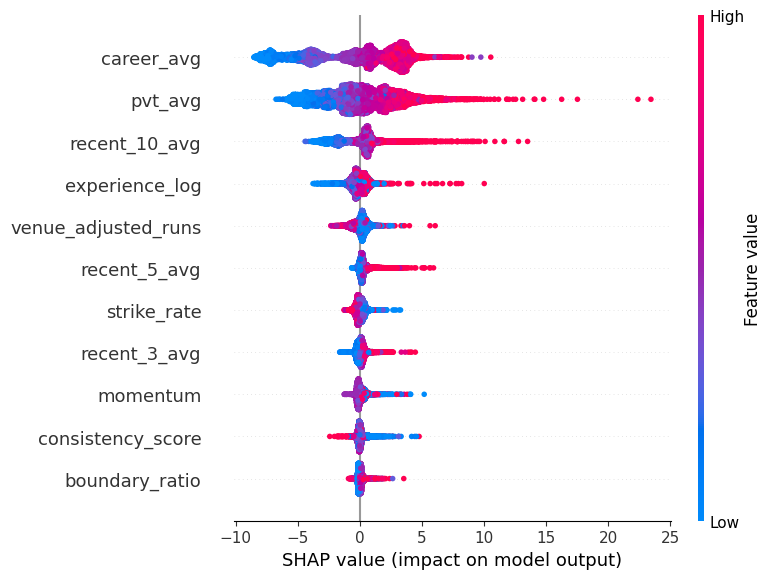

In [26]:
shap.summary_plot(rf_shap_values, X_train)


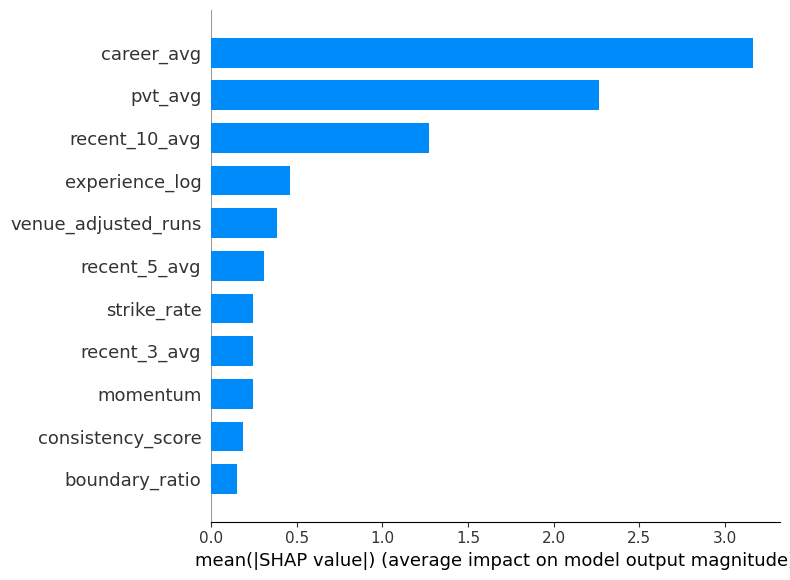

In [27]:
shap.summary_plot(rf_shap_values, X_train, plot_type="bar")


2.SHAP for XGBoost

In [28]:
xgb_explainer = shap.TreeExplainer(best_xgb)
xgb_shap_values = xgb_explainer.shap_values(X_train)


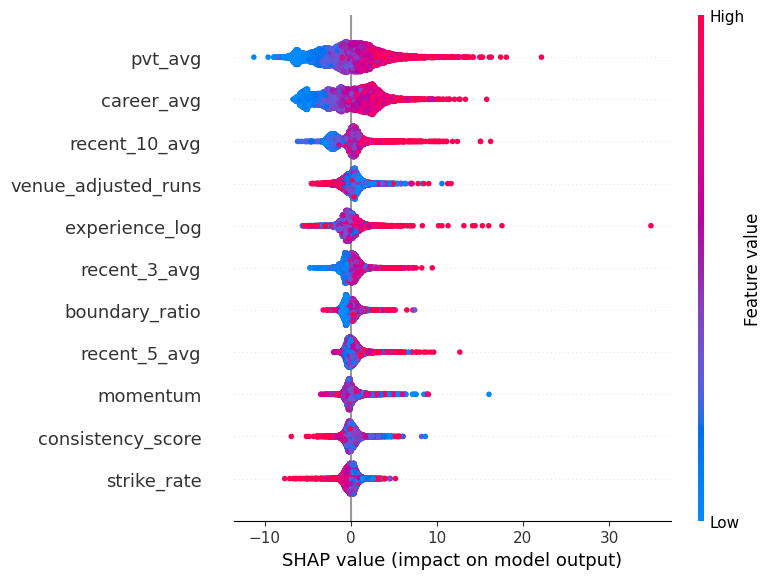

In [29]:
shap.summary_plot(xgb_shap_values, X_train)


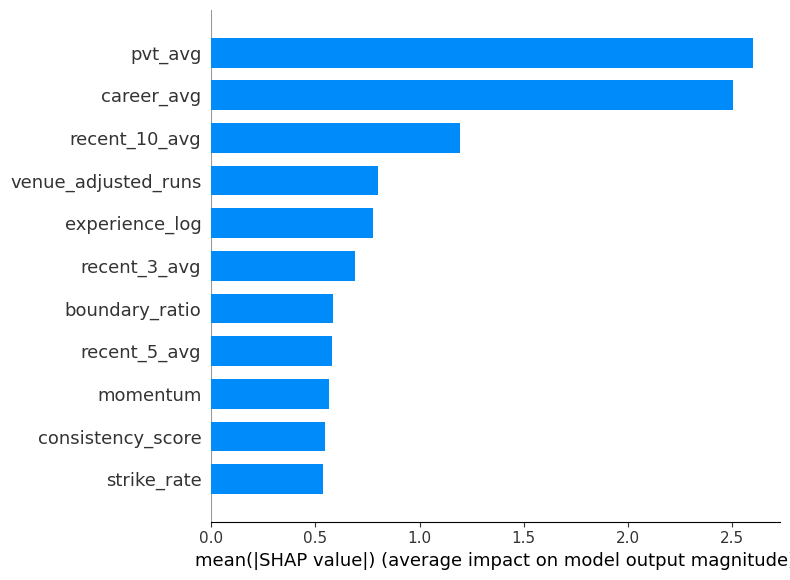

In [30]:
shap.summary_plot(xgb_shap_values, X_train, plot_type="bar")


3.SHAP for LightGBM

In [31]:
lgb_explainer = shap.TreeExplainer(best_lgb)
lgb_shap_values = lgb_explainer.shap_values(X_train)


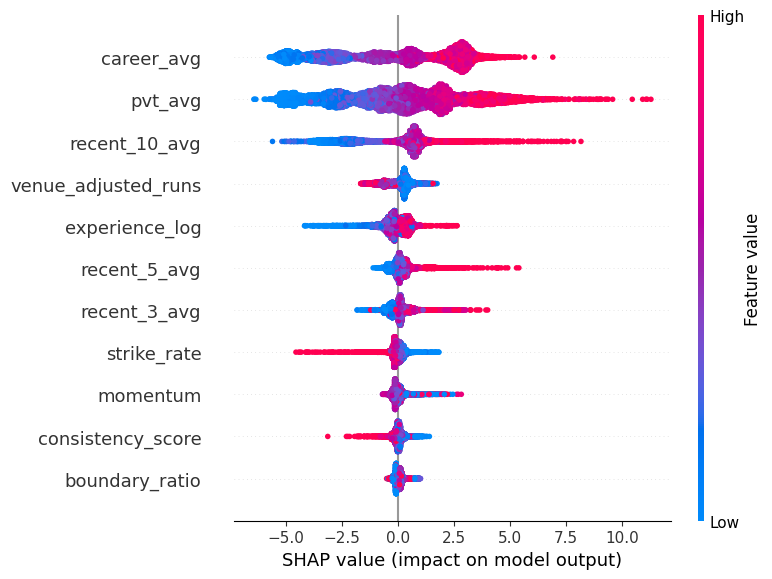

In [32]:
shap.summary_plot(lgb_shap_values, X_train)


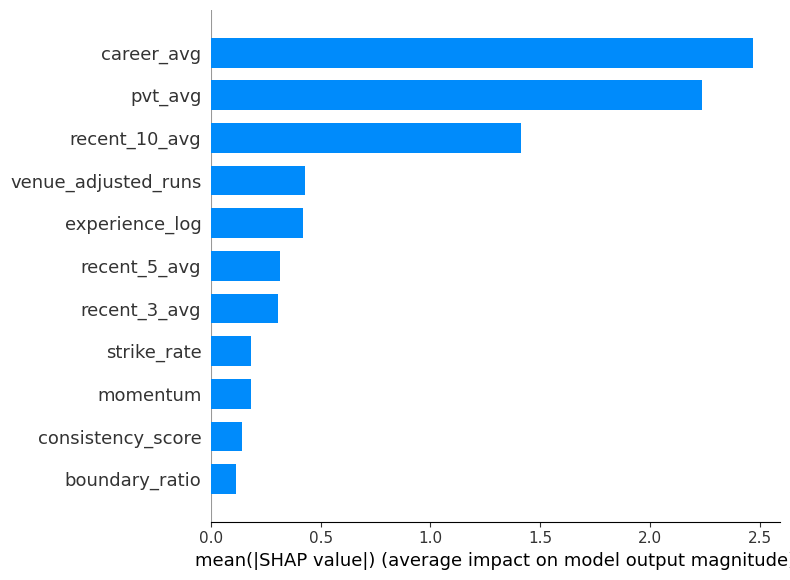

In [33]:
shap.summary_plot(lgb_shap_values, X_train, plot_type="bar")


SHAP Importance DataFrame (LightGBM)

In [34]:
shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": np.abs(lgb_shap_values).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

shap_importance


,feature,mean_abs_shap
0,career_avg,2.469826
9,pvt_avg,2.236913
3,recent_10_avg,1.412312
8,venue_adjusted_runs,0.429884
10,experience_log,0.419878
2,recent_5_avg,0.315359
1,recent_3_avg,0.303688
4,strike_rate,0.182642
7,momentum,0.180226
6,consistency_score,0.138802


Models Saved Using joblib

In [35]:
joblib.dump(best_rf, "../models/random_forest_model.joblib")
joblib.dump(best_xgb, "../models/xgboost_model.joblib")
joblib.dump(best_lgb, "../models/lightgbm_model.joblib")

print("All models saved successfully!")


All models saved successfully!


Saved Feature Names

In [36]:
joblib.dump(list(X_train.columns), "../models/feature_names.joblib")


['../models/feature_names.joblib']

In [37]:
joblib.dump(best_lgb, "../models/final_lightgbm_model.joblib")
print("Final LightGBM model saved successfully!")


Final LightGBM model saved successfully!
